# Fractal Interpolation Function (FIF)
-----------------------------------
 This notebook takes interpolation points $(x_n, y_n)$ and scaling factors $\alpha_n$
 and generates the corresponding fractal interpolation function.
## Theory:

 We define affine maps

   $$w_n(x, y) = (L_n(x), F_n(x,y))$$

 where

   $$L_n(x) = a_n x + b_n$$
   $$F_n(x,y) = \alpha_n y + c_n x + d_n$$

 satisfying

   $$L_n(x_0) = x_{n-1}$$
   $$L_n(x_N) = x_n$$

 and

   $$F_n(x_0, y_0) = y_{n-1}$$
   $$F_n(x_N, y_N) = y_n$$

 From these conditions:

  $$ a_n = \frac{(x_n - x_{n-1})} {(x_N - x_0)}$$

   $$b_n = \frac{(x_N x_{n-1} - x_0 x_n}{(x_N - x_0)}$$

   $$c_n = \frac{(y_n - y_{n-1}) - \alpha_n(y_N - y_0)}{(x_N - x_0)}$$

   $$d_n = \frac{(x_N y_{n-1} - x_0 y_n) - \alpha_n(x_N y_0 - x_0 y_N)}{(x_N - x_0)}$$











In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Example interpolation points
# Replace these with your own data

x = np.array([0, 1, 2, 3, 4], dtype=float)
y = np.array([0, 2, 1, 3, 0], dtype=float)

# alpha_n values
# Must satisfy |alpha_n| < 1

alpha = np.array([0.3, -0.4, 0.2, 0.5], dtype=float)

# Number of chaos game iterations
num_iterations = 200000

In [ ]:
# ============================================================
# BASIC CHECKS
# ============================================================
N = len(x) - 1

if len(alpha) != N:
    raise ValueError("Length of alpha must be N where number of points = N+1")

if np.any(np.abs(alpha) >= 1):
    raise ValueError("All alpha_n must satisfy |alpha_n| < 1")

if not np.all(np.diff(x) > 0):
    raise ValueError("x values must be strictly increasing")

In [ ]:
# ============================================================
# COMPUTE COEFFICIENTS
# ============================================================
x0 = x[0]
xN = x[-1]

y0 = y[0]
yN = y[-1]

a = np.zeros(N)
b = np.zeros(N)
c = np.zeros(N)
d = np.zeros(N)

for n in range(N):

    xn1 = x[n]
    xn = x[n + 1]

    yn1 = y[n]
    yn = y[n + 1]

    an = alpha[n]

    # L_n coefficients
    a[n] = (xn - xn1) / (xN - x0)

    b[n] = (xN * xn1 - x0 * xn) / (xN - x0)

    # F_n coefficients
    c[n] = (
        yn - yn1 - an * (yN - y0)
    ) / (xN - x0)

    d[n] = (
        xN * yn1
        - x0 * yn
        - an * (xN * y0 - x0 * yN)
    ) / (xN - x0)



In [5]:
print("Affine map coefficients:\n")

for n in range(N):
    print(f"Map w_{n+1}")
    print(f"a_{n+1} = {a[n]: .6f}")
    print(f"b_{n+1} = {b[n]: .6f}")
    print(f"c_{n+1} = {c[n]: .6f}")
    print(f"d_{n+1} = {d[n]: .6f}")
    print(f"alpha_{n+1} = {alpha[n]: .6f}")
    print("-" * 40)

Affine map coefficients:

Map w_1
a_1 =  0.250000
b_1 =  0.000000
c_1 =  0.500000
d_1 =  0.000000
alpha_1 =  0.300000
----------------------------------------
Map w_2
a_2 =  0.250000
b_2 =  1.000000
c_2 = -0.250000
d_2 =  2.000000
alpha_2 = -0.400000
----------------------------------------
Map w_3
a_3 =  0.250000
b_3 =  2.000000
c_3 =  0.500000
d_3 =  1.000000
alpha_3 =  0.200000
----------------------------------------
Map w_4
a_4 =  0.250000
b_4 =  3.000000
c_4 = -0.750000
d_4 =  3.000000
alpha_4 =  0.500000
----------------------------------------


In [ ]:
# ============================================================
# DEFINE AFFINE MAPS
# ============================================================

def w(n, X):

    xx, yy = X

    new_x = a[n] * xx + b[n]
    new_y = alpha[n] * yy + c[n] * xx + d[n]

    return np.array([new_x, new_y])



In [ ]:

# ============================================================
# RANDOM ITERATION ALGORITHM (CHAOS GAME)
# ============================================================
 
points = np.zeros((num_iterations, 2))

# Initial point
current = np.array([x0, y0], dtype=float)

for k in range(num_iterations):

    # Choose random map
    n = np.random.randint(0, N)

    # Apply map
    current = w(n, current)

    points[k] = current

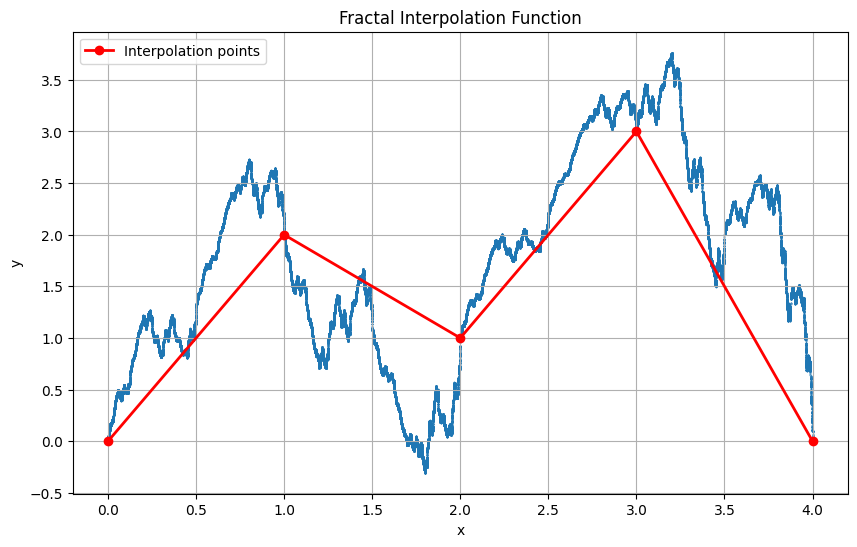

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=0.1
)

# Original interpolation points
plt.plot(
    x,
    y,
    'ro-',
    linewidth=2,
    markersize=6,
    label='Interpolation points'
)

plt.title("Fractal Interpolation Function")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True)

plt.show()